In [1]:
# Step 1 : create Data Pipeline

In [2]:
print("Climate Impact Analytics Pipeline Started")

Climate Impact Analytics Pipeline Started


In [3]:
# Importing Libraries
import pandas as pd
import requests
import json
import datetime as dt

In [84]:
print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
# Load the Cities Dataset
cities = pd.read_csv("../data/raw/cities_master.csv")

cities

,City,Country,Latitude,Longitude,Region,Population
0,Mumbai,India,19.076,72.877,Asia,20400000
1,Delhi,India,28.613,77.209,Asia,31800000
2,Bangalore,India,12.971,77.594,Asia,12400000
3,Chennai,India,13.082,80.270,Asia,11000000
4,Kolkata,India,22.572,88.363,Asia,15000000
...,...,...,...,...,...,...
95,Dar es Salaam,Tanzania,-6.792,39.208,Africa,6700000
96,Kampala,Uganda,0.347,32.582,Africa,1650000
97,Harare,Zimbabwe,-17.825,31.033,Africa,1480000
98,Dakar,Senegal,14.716,-17.467,Africa,1146000


In [5]:
# Check Dataset Structure
cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        100 non-null    object 
 1   Country     100 non-null    object 
 2   Latitude    100 non-null    float64
 3   Longitude   100 non-null    float64
 4   Region      100 non-null    object 
 5   Population  100 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ KB


In [6]:
# Prepare the Weather API

In [7]:
API_KEY = "2c756e7f9e35107c881ab434f7cf06d7"

In [8]:
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

In [9]:
# Test API with One City
lat = cities.loc[0, "Latitude"]
lon = cities.loc[0, "Longitude"]

params = {
    "lat": lat,
    "lon": lon,
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(BASE_URL, params=params)

response.json()

{'coord': {'lon': 72.877, 'lat': 19.076},
 'weather': [{'id': 711,
   'main': 'Smoke',
   'description': 'smoke',
   'icon': '50d'}],
 'base': 'stations',
 'main': {'temp': 30.17,
  'feels_like': 33.16,
  'temp_min': 28.97,
  'temp_max': 31.1,
  'pressure': 1011,
  'humidity': 60,
  'sea_level': 1011,
  'grnd_level': 1009},
 'visibility': 3000,
 'wind': {'speed': 4.12, 'deg': 260},
 'clouds': {'all': 0},
 'dt': 1773730713,
 'sys': {'type': 1,
  'id': 9052,
  'country': 'IN',
  'sunrise': 1773710129,
  'sunset': 1773753509},
 'timezone': 19800,
 'id': 8131499,
 'name': 'Konkan Division',
 'cod': 200}

In [10]:
#Step 9 — Build Automated Weather Data Pipeline for All 100 Cities 🌍

In [11]:
# Create Function to fetch wether data

In [13]:
import requests
import pandas as pd
from datetime import datetime,timedelta

def fetch_weather(city_row):
    lat = city_row['Latitude']
    lon = city_row['Longitude']
    city_name = city_row['City']
    country = city_row['Country']
    
    params = {
        "lat": lat,
        "lon": lon,
        "appid": API_KEY,
        "units": "metric"
    }
    
    try:
        response = requests.get(BASE_URL, params=params)
        data = response.json()
        
        # Extract useful info
        temp = data['main']['temp']
        humidity = data['main']['humidity']
        pressure = data['main']['pressure']
        weather_desc = data['weather'][0]['description']
        
        timestamp= data["dt"]
        date_time=datetime.utcfromtimestamp(timestamp)+timedelta(hours=5,minutes=30)
        
        return {
            "City": city_name,
            "Country": country,
            "Latitude": lat,
            "Longitude": lon,
            "Temperature": temp,
            "Humidity": humidity,
            "Pressure": pressure,
            "Weather_Description": weather_desc,
            "Datetime":date_time  
        }
    
    except Exception as e:
        print(f"Error fetching data for {city_name}: {e}")
        return None

In [14]:
# Test Fucntion for 1 city
test_data = fetch_weather(cities.iloc[0])
test_data

{'City': 'Mumbai',
 'Country': 'India',
 'Latitude': 19.076,
 'Longitude': 72.877,
 'Temperature': 30.17,
 'Humidity': 60,
 'Pressure': 1011,
 'Weather_Description': 'smoke',
 'Datetime': datetime.datetime(2026, 3, 17, 12, 28, 33)}

In [15]:
# Test for 100 cities
weather_data = []

for idx, row in cities.iterrows():
    data = fetch_weather(row)
    if data:
        weather_data.append(data)

        
weather_df = pd.DataFrame(weather_data)

weather_df.head()

,City,Country,Latitude,Longitude,Temperature,Humidity,Pressure,Weather_Description,Datetime
0,Mumbai,India,19.076,72.877,30.17,60,1011,smoke,2026-03-17 12:28:33
1,Delhi,India,28.613,77.209,27.07,44,1009,haze,2026-03-17 12:25:31
2,Bangalore,India,12.971,77.594,29.74,46,1010,scattered clouds,2026-03-17 12:28:03
3,Chennai,India,13.082,80.270,31.54,60,1010,few clouds,2026-03-17 12:21:23
4,Kolkata,India,22.572,88.363,29.96,51,1008,haze,2026-03-17 12:31:17


In [16]:
import os

file_path = "../data/raw/raw_weather_data.csv"

if os.path.exists(file_path):
    # Append new data, no header, datetime in proper format
    weather_df.to_csv(
        file_path,
        mode='a',
        header=False,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S"
    )
else:
    # First time: write with header
    weather_df.to_csv(
        file_path,
        mode='w',
        header=True,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S"
    )

# Data Cleaning

In [21]:
# Load Data 
import pandas as pd

weather_df = pd.read_csv("../data/raw/raw_weather_data.csv")
weather_df.head()

,City,Country,Latitude,Longitude,Temperature,Humidity,Pressure,Weather_Description,Datetime
0,Mumbai,India,19.076,72.877,30.17,60,1011,smoke,2026-03-17 12:28:33
1,Delhi,India,28.613,77.209,27.07,44,1009,haze,2026-03-17 12:25:31
2,Bangalore,India,12.971,77.594,29.74,46,1010,scattered clouds,2026-03-17 12:28:03
3,Chennai,India,13.082,80.270,31.54,60,1010,few clouds,2026-03-17 12:21:23
4,Kolkata,India,22.572,88.363,29.96,51,1008,haze,2026-03-17 12:31:17


In [22]:
print(len(weather_df))

100


In [23]:
weather_df["Datetime"] = pd.to_datetime(weather_df["Datetime"], errors="coerce")

In [24]:
# Check missing values
weather_df.isnull().sum()

City                   0
Country                0
Latitude               0
Longitude              0
Temperature            0
Humidity               0
Pressure               0
Weather_Description    0
Datetime               0
dtype: int64

In [25]:
weather_df["Temperature"].fillna(weather_df["Temperature"].mean(),inplace=True)
weather_df["Humidity"].fillna(weather_df["Humidity"].median(),inplace=True)
weather_df["Pressure"].fillna(method="ffill",inplace=True)

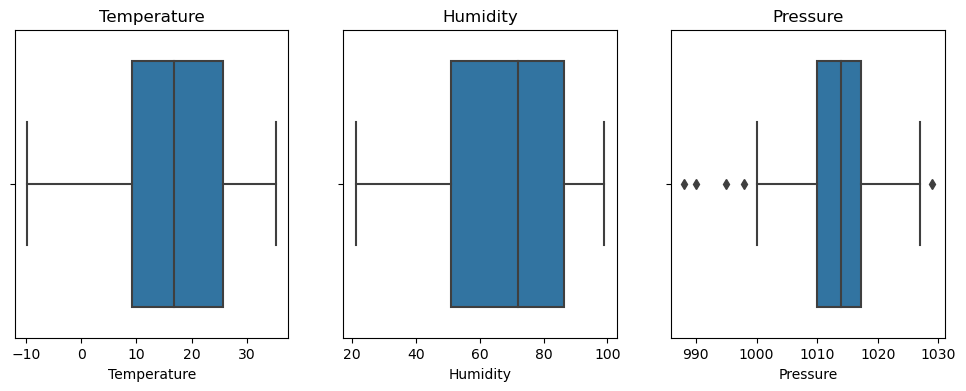

In [26]:
# detect outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(x=weather_df['Temperature'])
plt.title('Temperature')

plt.subplot(1,3,2)
sns.boxplot(x=weather_df['Humidity'])
plt.title('Humidity')

plt.subplot(1,3,3)
sns.boxplot(x=weather_df['Pressure'])
plt.title('Pressure')

plt.show()

In [27]:
Q1 = weather_df['Temperature'].quantile(0.25)
Q3 = weather_df['Temperature'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

weather_df['Temperature'] = weather_df['Temperature'].clip(lower, upper)

In [28]:
Q1 = weather_df['Humidity'].quantile(0.25)
Q3 = weather_df['Humidity'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

weather_df['Humidity'] = weather_df['Humidity'].clip(lower, upper)

In [29]:
Q1 = weather_df['Pressure'].quantile(0.25)
Q3 = weather_df['Pressure'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

weather_df['Pressure'] = weather_df['Pressure'].clip(lower, upper)

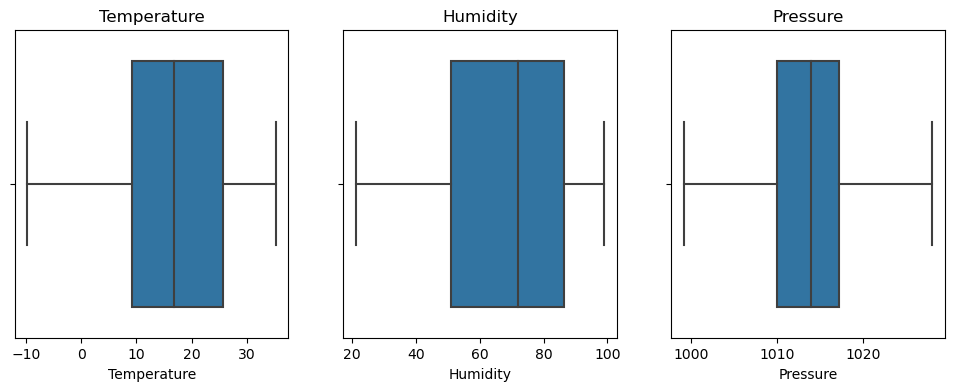

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(x=weather_df['Temperature'])
plt.title('Temperature')

plt.subplot(1,3,2)
sns.boxplot(x=weather_df['Humidity'])
plt.title('Humidity')

plt.subplot(1,3,3)
sns.boxplot(x=weather_df['Pressure'])
plt.title('Pressure')

plt.show()

In [31]:
# Check Skewness
weather_df[['Temperature', 'Humidity', 'Pressure']].skew()

Temperature   -0.264626
Humidity      -0.414286
Pressure      -0.168528
dtype: float64

In [32]:
import numpy as np

# Select only required numeric columns from your dataframe
num_cols = weather_df[["Temperature", "Humidity", "Pressure"]]

for col in num_cols.columns:
    skew = weather_df[col].skew()
    print(f"{col} skewness before: {skew}")
    
    # Apply transformation based on skewness
    if skew > 1:
        weather_df[col] = np.log1p(weather_df[col])
        print(f"{col} → Log Transformation Applied")
        
    elif skew < -1:
        weather_df[col] = np.square(weather_df[col])
        print(f"{col} → Square Transformation Applied")
        
    else:
        print(f"{col} → No Transformation Needed")

# Final skewness check
print("\nAfter Transformation:")
print(weather_df[["Temperature", "Humidity", "Pressure"]].skew())

Temperature skewness before: -0.2646256444808554
Temperature → No Transformation Needed
Humidity skewness before: -0.41428624870113834
Humidity → No Transformation Needed
Pressure skewness before: -0.16852809543527375
Pressure → No Transformation Needed

After Transformation:
Temperature   -0.264626
Humidity      -0.414286
Pressure      -0.168528
dtype: float64


In [33]:
# Saved Cleanded data 
import os

# path for processed data
processed_path = "../data/processed/clean_weather_data.csv"

# create folder if it does not exist
os.makedirs("../data/processed", exist_ok=True)

# save cleaned dataset
weather_df.to_csv(processed_path, index=False)

print("Cleaned data saved successfully!")

Cleaned data saved successfully!


In [34]:
import pandas as pd
import os

# Path of cleaned file
file_path = "../data/processed/clean_weather_data.csv"

# New cleaned data (current run)
new_df = weather_df.copy()

# Convert datetime (important)
new_df["Datetime"] = pd.to_datetime(new_df["Datetime"], errors="coerce")

# Load old data if exists
if os.path.exists(file_path):
    old_df = pd.read_csv(file_path)
    old_df["Datetime"] = pd.to_datetime(old_df["Datetime"], errors="coerce")
else:
    old_df = pd.DataFrame()

# Combine old + new data
combined_df = pd.concat([old_df, new_df], ignore_index=True)

# Remove duplicates (City + Datetime)
combined_df.drop_duplicates(subset=["City", "Datetime"], keep="last", inplace=True)

# Save back to cleaned file
combined_df.to_csv(file_path, index=False)

print("✅ Duplicate handling done successfully!")

✅ Duplicate handling done successfully!


In [35]:
# Load Cleanne wether data
import pandas as pd

df = pd.read_csv("../data/processed/clean_weather_data.csv")
df.head()

,City,Country,Latitude,Longitude,Temperature,Humidity,Pressure,Weather_Description,Datetime
0,Mumbai,India,19.076,72.877,30.17,60,1011.0,smoke,2026-03-17 12:28:33
1,Delhi,India,28.613,77.209,27.07,44,1009.0,haze,2026-03-17 12:25:31
2,Bangalore,India,12.971,77.594,29.74,46,1010.0,scattered clouds,2026-03-17 12:28:03
3,Chennai,India,13.082,80.270,31.54,60,1010.0,few clouds,2026-03-17 12:21:23
4,Kolkata,India,22.572,88.363,29.96,51,1008.0,haze,2026-03-17 12:31:17


In [36]:
df.describe()

,Latitude,Longitude,Temperature,Humidity,Pressure
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,20.992420,12.794430,16.429700,67.600000,1013.596250
std,27.698087,81.665577,10.643858,20.695971,6.036318
min,-41.286000,-149.900000,-9.750000,21.000000,999.125000
25%,5.380000,-67.207000,9.132500,51.000000,1010.000000
50%,29.018500,13.921000,16.725000,72.000000,1014.000000
75%,41.080750,77.817000,25.615000,86.250000,1017.250000
max,61.218000,174.776000,35.240000,99.000000,1028.125000


In [37]:
# convert datetime
df["Datetime"]=pd.to_datetime(df["Datetime"])

# Get latest record for each city 
latest_df=df.sort_values("Datetime").groupby("City").tail(1)

print(latest_df[["City","Temperature","Datetime"]])

             City  Temperature            Datetime
53         Sydney        25.66 2026-03-17 12:19:55
3         Chennai        31.54 2026-03-17 12:21:23
29  San Francisco        16.93 2026-03-17 12:21:24
37          Seoul        14.76 2026-03-17 12:21:29
51           Doha        29.38 2026-03-17 12:21:57
..            ...          ...                 ...
95  Dar es Salaam        29.95 2026-03-17 12:33:36
96        Kampala        26.83 2026-03-17 12:33:38
97         Harare        16.57 2026-03-17 12:33:39
98          Dakar        19.95 2026-03-17 12:33:41
99        Tripoli        11.94 2026-03-17 12:33:43

[100 rows x 3 columns]


In [38]:
# Compare Regions
# Merge region info if not present
cities = pd.read_csv("../data/raw/cities_master.csv")
latest_df = latest_df.merge(cities[['City', 'Region']], on='City', how='left')

# Average temperature by region
region_temp = latest_df.groupby('Region')['Temperature'].mean().sort_values(ascending=False)
region_temp

Region
Asia             25.231667
Oceania          23.383333
Middle East      22.058000
Africa           20.173333
South America    18.799091
North America     7.978000
Europe            6.203684
Name: Temperature, dtype: float64

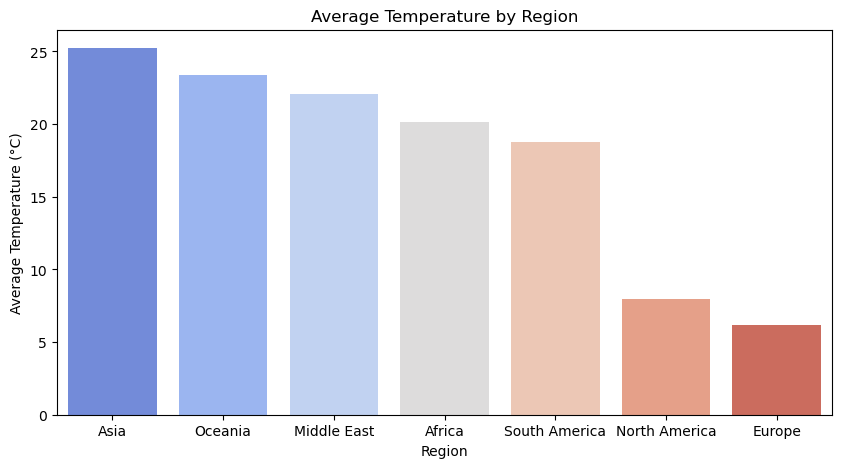

In [39]:
# Temperature by region 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=region_temp.index, y=region_temp.values, palette="coolwarm")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature by Region")
plt.show()

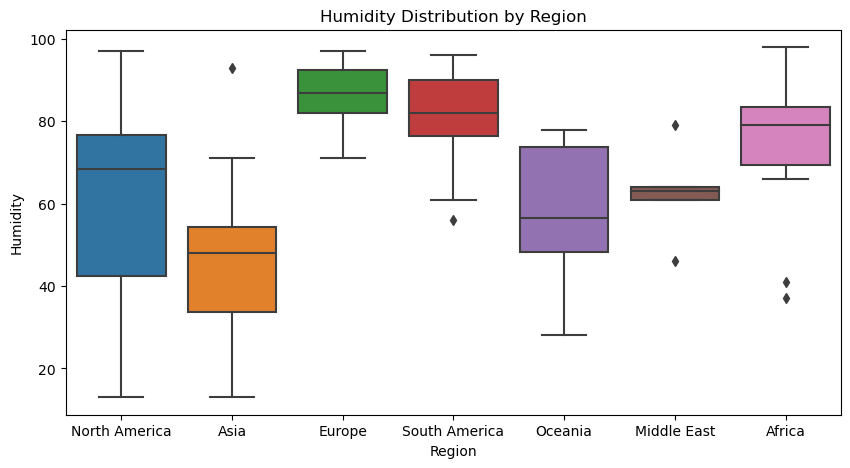

In [122]:
# Plot Humidity Distribution
plt.figure(figsize=(10,5))
sns.boxplot(x='Region', y='Humidity', data=latest_df)
plt.title("Humidity Distribution by Region")
plt.show()

In [40]:
# Top Ten Hotest cities
top_cities = latest_df.sort_values(by='Temperature', ascending=False).head(10)
top_cities[['City','Country','Temperature']]

,City,Country,Temperature
16,Kuala Lumpur,Malaysia,35.24
17,Perth,Australia,33.90
65,Jakarta,Indonesia,32.63
24,Colombo,Sri Lanka,32.25
27,Singapore,Singapore,32.16
5,Dhaka,Bangladesh,31.99
14,Bangkok,Thailand,31.86
1,Chennai,India,31.54
37,Hyderabad,India,31.23
26,Mumbai,India,30.17


In [41]:
# Top Ten Most Humid Cities
top_humidity = latest_df.sort_values(by='Humidity', ascending=False).head(10)

top_humidity[['City','Country','Humidity']]

,City,Country,Humidity
93,Asuncion,Paraguay,99
51,Copenhagen,Denmark,98
52,Helsinki,Finland,98
97,Harare,Zimbabwe,97
59,Vancouver,Canada,97
60,Montreal,Canada,96
49,Stockholm,Sweden,94
50,Oslo,Norway,94
94,Caracas,Venezuela,94
90,Quito,Ecuador,93


In [44]:
# Top Ten Hotest cities
top_humidity = latest_df.sort_values(by='Temperature', ascending=False).head(10)

top_humidity[['City','Country','Temperature']]

,City,Country,Temperature
16,Kuala Lumpur,Malaysia,35.24
17,Perth,Australia,33.90
65,Jakarta,Indonesia,32.63
24,Colombo,Sri Lanka,32.25
27,Singapore,Singapore,32.16
5,Dhaka,Bangladesh,31.99
14,Bangkok,Thailand,31.86
1,Chennai,India,31.54
37,Hyderabad,India,31.23
26,Mumbai,India,30.17


In [45]:
# top 10 coldest cities
top_humidity = latest_df.sort_values(by='Temperature', ascending=True).head(10)

top_humidity[['City','Country','Temperature']]

,City,Country,Temperature
89,Anchorage,USA,-9.75
54,Chicago,USA,-8.06
58,Toronto,Canada,-6.74
88,Detroit,USA,-6.26
60,Montreal,Canada,0.52
51,Copenhagen,Denmark,0.79
50,Oslo,Norway,1.47
42,Berlin,Germany,1.73
52,Helsinki,Finland,1.73
11,Dallas,USA,1.91


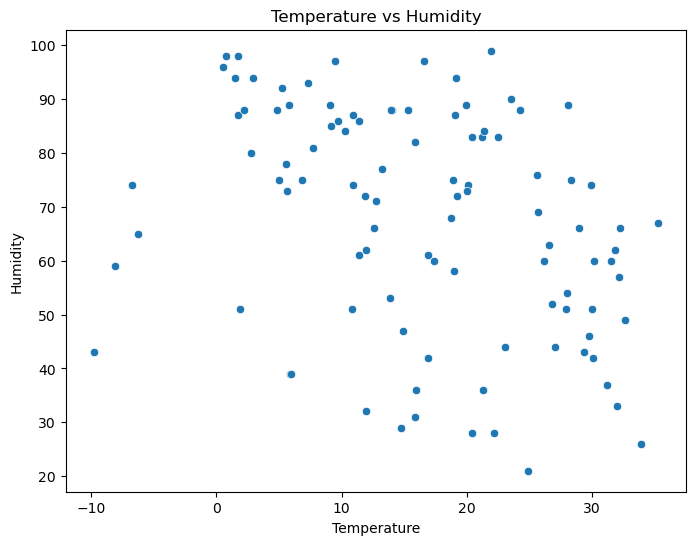

In [46]:
# Temperature vs Humidity
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Temperature',
    y='Humidity',
    data=latest_df
)

plt.title("Temperature vs Humidity")

plt.show()

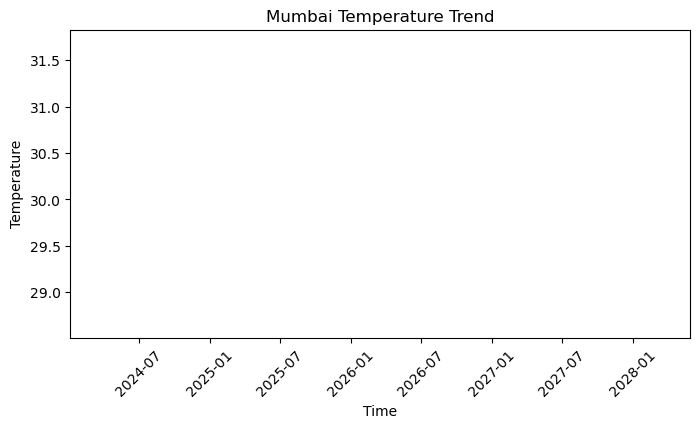

In [47]:
# City temperature Trend (Time Series)
# Example of mumbai Trend
mumbai_df=df[df["City"]=="Mumbai"].sort_values("Datetime")

import matplotlib.pyplot as plt 

plt.figure(figsize=(8,4))
plt.plot(mumbai_df["Datetime"],mumbai_df["Temperature"])
plt.title("Mumbai Temperature Trend")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

In [48]:
# Hourly Average Temeprature 
df["Hour"]=df["Datetime"].dt.hour

hourly_avg=df.groupby("Hour")["Temperature"].mean().reset_index()
print(hourly_avg)

   Hour  Temperature
0    12      16.4297


In [49]:
# Daily Aggregation 
df["Date"]=df["Datetime"].dt.date

daily_stats=df.groupby(["City","Date"]).agg({"Temperature":["mean","max","min"]}).reset_index()

daily_stats.columns=["City","Date","Avg_temp","Max_Temp","Min_Temp"]
print(daily_stats.head())

          City        Date  Avg_temp  Max_Temp  Min_Temp
0    Abu Dhabi  2026-03-17     26.16     26.16     26.16
1        Accra  2026-03-17     28.05     28.05     28.05
2  Addis Ababa  2026-03-17     21.26     21.26     21.26
3      Algiers  2026-03-17     10.86     10.86     10.86
4    Amsterdam  2026-03-17      9.08      9.08      9.08


In [52]:
df.to_csv("../data/processed/climate_dashboard_dataset.csv", index=False)

In [53]:
len(weather_df)

100